# Tutorial 9: Integrating mouse, marmoset and macaque 3D reconstructed cerebellums (Stereo-seq)


## Dataset link
https://drive.google.com/file/d/19BmjjljY8ssr4CDj1gNypYhOPpJ4JFsD/view?usp=drive_link

## GPU memory requirements
15GB

## Running time



## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../')
import STACAME 
import os
os.environ['R_HOME'] = "/data/zhanglab/zhangbiao/anaconda3/envs/env_stasage/lib/R"
os.environ['R_USER'] = "/data/zhanglab/zhangbiao/anaconda3/envs/env_stasage/lib/python3.11/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg
from scipy.sparse import csr_matrix
import pandas as pd
import torch
from STACAME.analysis import merge_embedding
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score
import seaborn as sns

import colorcet as cc

In [3]:
# data_path =  '../Experiment_3d_cerebellar/3d_visualization/stitch3d_spateo/Mouse/'
# section_name_list = ['adata_st']
# for section_name in section_name_list:
#     save_section_name = section_name
#     section_name = section_name + '.h5ad'
#     adata = sc.read_h5ad(data_path + section_name)
#     adata.obsm['spatial'] = adata.obsm['3D_coor']
#     sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
#     adata = adata[:, adata.var['highly_variable']]
#     adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

In [4]:
# data_path =  '../Experiment_3d_cerebellar/3d_visualization/stitch3d_spateo/Marmoset/'
# section_name_list = ['adata_st']
# for section_name in section_name_list:
#     save_section_name = section_name
#     section_name = section_name + '.h5ad'
#     adata = sc.read_h5ad(data_path + section_name)
#     adata.obsm['spatial'] = adata.obsm['3D_coor']
#     sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
#     adata = adata[:, adata.var['highly_variable']]
#     adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

In [5]:

# data_path =  '../Experiment_3d_cerebellar/3d_visualization/stitch3d_spateo/Macaque/'
# section_name_list = ['adata_st']
# for section_name in section_name_list:
#     save_section_name = section_name
#     section_name = section_name + '.h5ad'
#     adata = sc.read_h5ad(data_path + section_name)
#     adata.obsm['spatial'] = adata.obsm['3D_coor']
#     sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
#     adata = adata[:, adata.var['highly_variable']]
#     adata.write_h5ad(data_path + save_section_name  + '_load' + '.h5ad')

In [6]:
def clustering_umap_spatial(adata_dict, key_umap='STACAME'):
    k = 0
    for species_id, adata in adata_dict.items():
        if k == 0:
            embedding_X = adata.obsm[key_umap]
            embedding_spatial = adata.obsm['spatial']
            embedding_obs_name = list(adata.obs_names)
            embedding_slice_name = list(adata.obs['slice_name']) 
            embedding_batch_name = list(adata.obs['batch_name'])
            embedding_species_id = list(adata.obs['species_id'])
            embedding_annotation = list(adata.obs['annotation'])
        else:
            embedding_X = np.concatenate((embedding_X, adata.obsm[key_umap]), axis=0)
            embedding_spatial = np.concatenate((embedding_spatial, adata.obsm['spatial']), axis=0)
            embedding_obs_name = embedding_obs_name + list(adata.obs_names)
            embedding_slice_name = embedding_slice_name + list(adata.obs['slice_name']) 
            embedding_batch_name = embedding_batch_name + list(adata.obs['batch_name'])
            embedding_species_id = embedding_species_id + list(adata.obs['species_id'])
            embedding_annotation = embedding_annotation + list(adata.obs['annotation'])
        k += 1

        #adata_dict[species_id] = adata

    adata_embedding = ad.AnnData(X = embedding_X, obs=embedding_obs_name)
    adata_embedding.obsm['spatial'] = embedding_spatial
    adata_embedding.obs['slice_name'] = embedding_slice_name
    adata_embedding.obs['batch_name'] = embedding_batch_name
    adata_embedding.obs['species_id'] = embedding_species_id
    adata_embedding.obs['annotation'] = embedding_annotation
    
    sc.pp.neighbors(adata_embedding,  n_neighbors=20, use_rep='X', metric='cosine',  random_state=666)
    sc.tl.louvain(adata_embedding, random_state=666, key_added="louvain", resolution=0.5)
    #sc.tl.leiden(adata_embedding, random_state=666, key_added="leiden", resolution=0.1)
    print(adata_embedding.X.shape)
    sc.tl.umap(adata_embedding, min_dist=1, random_state=666)
    species_ids = list(adata_dict.keys())
    
    species_color = ['#4778FA', '#8A4AA2', '#ED7A43'] #['#ff7f0e', '#1f77b4'] #'#8A1C62',
    species_color_dict = dict(zip(species_ids, species_color))
    adata_embedding.uns['species_colors'] = [species_color_dict[x] for x in adata_embedding.obs.species_id]
    plt.rcParams['font.sans-serif'] = "Arial"
    plt.rcParams["figure.figsize"] = (4, 4)
    plt.rcParams['font.size'] = 10
    # mclust clustering
    for i in range(len(species_ids)):
        species_id = species_ids[i]
        adata_mh = adata_embedding[adata_embedding.obs['species_id'].isin([species_id])]
       
        num_clusters = len(adata_mh.obs['annotation'].unique())
        
        adata_mh.obsm[key_umap] = adata_mh.X
        STACAME.mclust_R(adata_mh, num_cluster=num_clusters, used_obsm=key_umap)
        
        print('mclust, ARI = %01.3f' % ari_score(adata_mh.obs['annotation'], adata_mh.obs['mclust']))
        
        sc.pl.umap(adata_mh, color=['annotation', 'mclust'], ncols=2, wspace=0.5, show=True)
        color_list = sns.color_palette(cc.glasbey, n_colors=len(adata_mh.obs['annotation'].unique())).as_hex()
        print(color_list)
       
        region_list = ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
    
        palette = {k:v for k,v in zip(region_list, color_list)}
        sc.pl.umap(adata_mh, color='annotation',  wspace=0.5, show=False, palette = palette, size=10, legend_loc='on data') #legend_fontweight='normal',
    plt.show()
    return adata_dict, adata_embedding


def combine_adata(adata_dict, key_umap='STACAME'):
    k = 0
    for species_id, adata in adata_dict.items():
        if k == 0:
            embedding_X = adata.obsm[key_umap]
            embedding_spatial = adata.obsm['spatial']
            embedding_obs_name = list(adata.obs_names)
            embedding_slice_name = list(adata.obs['slice_name']) 
            embedding_batch_name = list(adata.obs['batch_name'])
            embedding_species_id = list(adata.obs['species_id'])
            embedding_annotation = list(adata.obs['annotation'])
        else:
            embedding_X = np.concatenate((embedding_X, adata.obsm[key_umap]), axis=0)
            embedding_spatial = np.concatenate((embedding_spatial, adata.obsm['spatial']), axis=0)
            embedding_obs_name = embedding_obs_name + list(adata.obs_names)
            embedding_slice_name = embedding_slice_name + list(adata.obs['slice_name']) 
            embedding_batch_name = embedding_batch_name + list(adata.obs['batch_name'])
            embedding_species_id = embedding_species_id + list(adata.obs['species_id'])
            embedding_annotation = embedding_annotation + list(adata.obs['annotation'])
        k += 1

        #adata_dict[species_id] = adata

    adata_embedding = ad.AnnData(X = embedding_X, obs=embedding_obs_name)
    adata_embedding.obsm['spatial'] = embedding_spatial
    adata_embedding.obs['slice_name'] = embedding_slice_name
    adata_embedding.obs['batch_name'] = embedding_batch_name
    adata_embedding.obs['species_id'] = embedding_species_id
    adata_embedding.obs['annotation'] = embedding_annotation
    return adata_dict, adata_embedding

In [7]:
import pickle

root_data_path = './Data/9_Cerebellar_3d/'
Gene_map_raw_path = './Data/9_Cerebellar_3d/Mouse_Marmoset_Macaque.tsv'
rad_cutoff_dict = {'Mouse':1.05, 'Marmoset':1.05, 'Macaque':1.05}
species_section_ids = {'Mouse':['adata_st_load_3sections'],
                       'Marmoset':['adata_st_load_3sections'],
                       'Macaque':['adata_st_load_3sections']}
species_ortholog_column_dict = {'Mouse':'Gene name', 
                                'Marmoset':'White-tufted-ear marmoset gene name', 
                               'Macaque':'Macaque gene name'}
species_ortholog_type_dict = {'Marmoset':'White-tufted-ear marmoset homology type', 
                               'Macaque':'Macaque homology type'}
species_id_map = {'Mouse':0, 'Marmoset':1, 'Macaque':2}


output_path = root_data_path + 'output_STACAME/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

load_processed = False

if load_processed:
    with open(output_path + 'adata_dict.pkl', 'rb') as fp:
        adata_dict = pickle.load(fp)
    with open(output_path + 'triplet_ind_species_dict.pkl', 'rb') as fp:
        triplet_ind_species_dict = pickle.load(fp)
    edge_ndarray_species = np.load(output_path + 'edge_ndarray_species.npy') 
    with open(output_path + 'triplet_ind_sections_dict.pkl', 'rb') as fp:
        triplet_ind_sections_dict = pickle.load(fp)
    edge_ndarray_sections = np.load(output_path + 'edge_ndarray_sections.npy') 
else:
    STACAME_processer = STACAME.STACAME_processer_subgraph(root_data_path=root_data_path,
                 Gene_map_raw_path=Gene_map_raw_path, 
                 species_section_ids = species_section_ids, 
                 species_ortholog_column_dict = species_ortholog_column_dict, 
                 species_ortholog_type_dict = species_ortholog_type_dict, 
                 species_id_map = species_id_map, 
                 rad_cutoff_dict = rad_cutoff_dict,
                 gene_cap_upper_dict = {'Mouse':'capitalize', 'Marmoset':'upper', 'Macaque':'upper'},
                 Down_sampling_adata = None, 
                 n_top_genes = 500, 
                 homo_n_top_genes = 1500, 
                 cross_species_neibors_K_mnn = 5, 
                 cross_sections_neibors_K_mnn = 1,
                 Smooth_spatial_neighbors = {'Mouse':0, 'Marmoset':0, 'Macaque':0}, 
                 total_normalize = {'Mouse':1e4, 'Marmoset':1e4, 'Macaque':1e4},
                 if_hvg_before_mnn = False, 
                 if_integrate_within_species = True, 
                 if_combat_mnn = False, 
                 if_pca_before_mnn = True, 
                 pca_dim_before_mnn = 40, 
                 if_return_concat_adata = False)
    
    adata_dict, triplet_ind_species_dict, edge_ndarray_species, triplet_ind_sections_dict, edge_ndarray_sections = STACAME_processer.load_process_adata_3d()
   
    with open(output_path + 'adata_dict.pkl', 'wb') as fp:
        pickle.dump(adata_dict, fp)
    with open(output_path + 'triplet_ind_species_dict.pkl', 'wb') as fp:
        pickle.dump(triplet_ind_species_dict, fp)
    with open(output_path + 'triplet_ind_sections_dict.pkl', 'wb') as fp:
        pickle.dump(triplet_ind_sections_dict, fp)
    np.save(output_path + 'edge_ndarray_species.npy', edge_ndarray_species)
    np.save(output_path + 'edge_ndarray_sections.npy', edge_ndarray_sections)

self.rad_cutoff_dict: {'Mouse': {'adata_st_load_3sections': 1.05}, 'Marmoset': {'adata_st_load_3sections': 1.05}, 'Macaque': {'adata_st_load_3sections': 1.05}}
--------------------------Species-Mouse-------------------------------
Species: Mouse Section: adata_st_load_3sections
(209938, 3)
Before flitering:  (209938, 5000)
After flitering:  (209938, 4927)
Number of genes: 4927
Before flitering:  (209938, 5000)
After flitering:  (209938, 4927)
Number of hvgs: 4927
Number of common hvgs: 4927
--------------------------Species-Marmoset-------------------------------
Species: Marmoset Section: adata_st_load_3sections
(247751, 3)
Before flitering:  (247751, 5000)
After flitering:  (247751, 4999)
Number of genes: 4999
Before flitering:  (247751, 5000)
After flitering:  (247751, 4999)
Number of hvgs: 4999
Number of common hvgs: 4999
--------------------------Species-Macaque-------------------------------
Species: Macaque Section: adata_st_load_3sections
(806522, 3)
Before flitering:  (806522,

## Running STACAME

For Mouse, using 1040 genes for training.
Pretrain with STAGATE (Minibatch)...


100%|██████████| 100/100 [18:56<00:00, 11.36s/it]


For Marmoset, using 1040 genes for training.
Pretrain with STAGATE (Minibatch)...


100%|██████████| 30/30 [06:06<00:00, 12.21s/it]


For Macaque, using 1040 genes for training.
Pretrain with STAGATE (Minibatch)...


...

---------------------------------Epoch 48-----------------------------------
Total loss: 43.58408737182617
MSE:0.31945183873176575, Cross species triplets:5.135728716850281, MMD:6.04996919631958, GAN: -0.019864702597260475
Cosine cross species loss:0.16786153614521027, Cross slices triplets: 0.3209879994392395


 98%|█████████▊| 49/50 [1:06:14<01:19, 79.78s/it]

---------------------------------Epoch 49-----------------------------------
Total loss: 37.851280212402344
MSE:0.3190295696258545, Cross species triplets:5.206982493400574, MMD:0.9353232383728027, GAN: -0.008579880930483341
Cosine cross species loss:0.19930633902549744, Cross slices triplets: 0.31398525834083557


100%|██████████| 50/50 [1:07:34<00:00, 81.09s/it]


Clustering and UMAP of Cross Species STACAME:


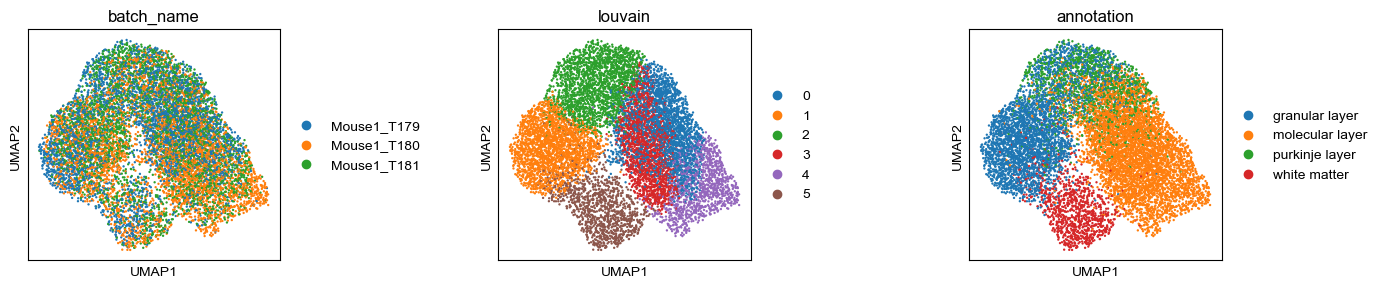

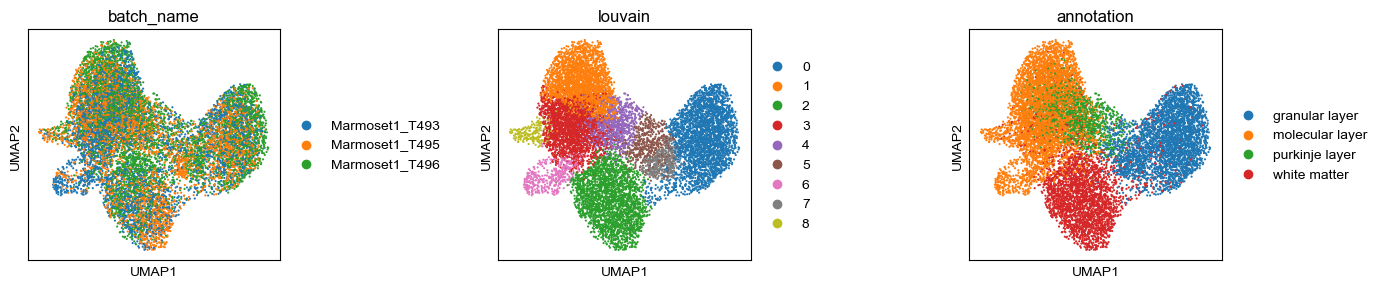

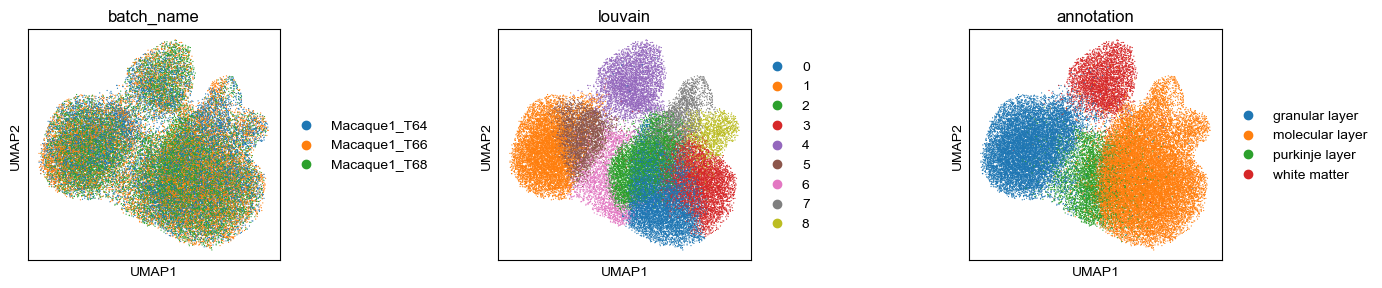

(63209, 16)


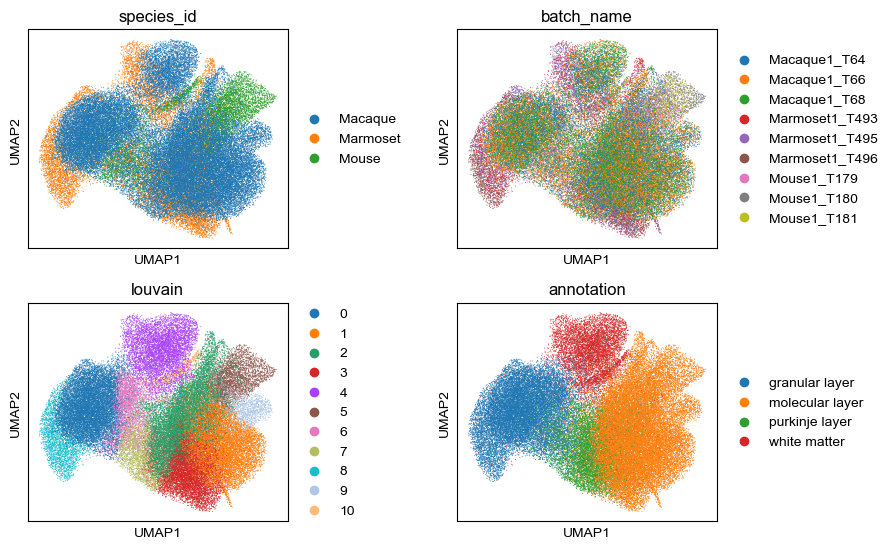

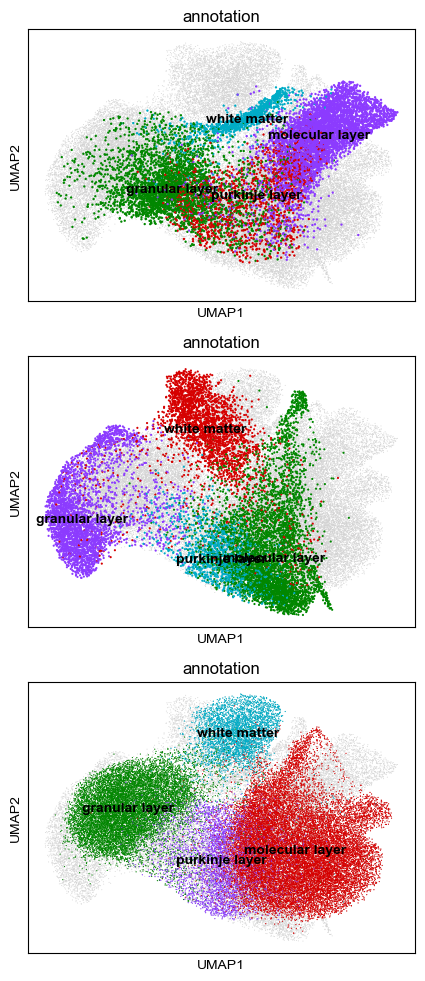

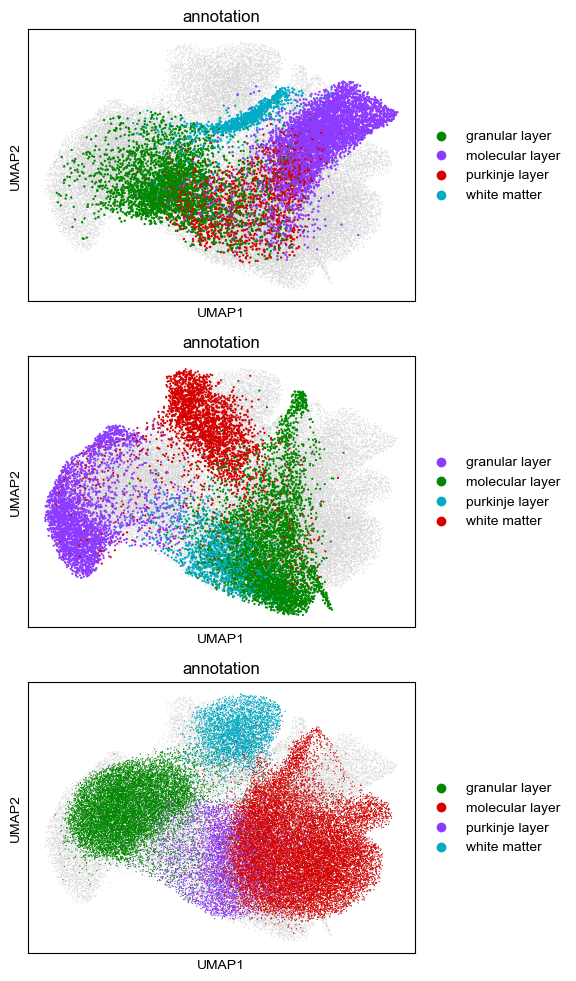

CPU times: user 2d 7h 6min 24s, sys: 4h 34min 34s, total: 2d 11h 40min 59s
Wall time: 1h 59min 13s


In [8]:
%%time
import importlib
from STACAME.train_STACAME import train_STACAME_subgraph
used_device = torch.device('cuda:4' if torch.cuda.is_available() else 'cpu')
pretrain_device = used_device

adata_species_dict = train_STACAME_subgraph(adata_dict, 
                           triplet_ind_species_dict = triplet_ind_species_dict, 
                           edge_ndarray_species = edge_ndarray_species, 
                           triplet_ind_sections_dict = triplet_ind_sections_dict, 
                           edge_ndarray_sections = edge_ndarray_sections,
                           hidden_dims=[256, 16], 
                           verbose=True, 
                           key_added = 'STACAME',
                           device=used_device, 
                           stagate_epoch={'Mouse':100, 'Marmoset':30, 'Macaque':30}, 
                           n_epochs_species=50,
                           margin_species=1,
                           lr=0.001, 
                           lr_species = 0.001,
                           pretrain_device = pretrain_device,
                           mse_beta = 1, 
                           beta = 100,
                           tri_beta = 10, 
                           mmd_beta = 10,
                           mmd_batch_size = 2048, 
                           batch_size = 5000,
                           batch_size_dict = {'Mouse': 10000, 'Marmoset':10000, 'Macaque':10000},
                           if_knn_mnn_graph = False, 
                           umap_downsampling_rate = 0.05, if_integrate_within_species = True)

## Save STACAME embeddings

In [9]:

adata_dict, adata_embedding = combine_adata(adata_species_dict, key_umap='STACAME')

In [10]:

for species_id, adata in adata_dict.items():
    if 'edgeList' in adata.uns.keys():
        del adata.uns['edgeList']
    adata.write(output_path + f'{species_id}.h5ad')
    adata_temp = adata[:, adata.uns['highly_variable']]
    adata_temp.var.index.name = None
    adata_temp.write(output_path + f'adata_{species_id}_expression.h5ad')

from STACAME.analysis import merge_embedding
adata_embedding = merge_embedding(adata_dict, key_umap = 'STACAME')
adata_embedding.obs['region_name'] = adata_embedding.obs['annotation']
adata_embedding.write(output_path + 'adata_embedding.h5ad')

In [11]:
from sklearn.metrics import adjusted_rand_score as ari_score

import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc

plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 10
fig_format = 'jpg'
fig_dpi = 500
annotation_num = 4

key_umap = 'STACAME'
fig_save_path = output_path


## Do clustering

In [12]:
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.size'] = 10
fig_format = 'jpg'
fig_dpi = 500
annotation_num = 4
fig_save_path = output_path
num_clusters =annotation_num
print(f'Mclust {num_clusters} clusters...')
STACAME.mclust_R(adata_embedding, num_cluster=num_clusters, used_obsm='STACAME')

   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



Mclust 4 clusters...
fitting ...
  |======================================================================| 100%
'Mclust' model object: (EEE,4) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   



AnnData object with n_obs × n_vars = 1264211 × 16
    obs: 'slice_name', 'batch_name', 'species_id', 'annotation', 'region_name', 'mclust'
    obsm: 'spatial', 'STACAME'

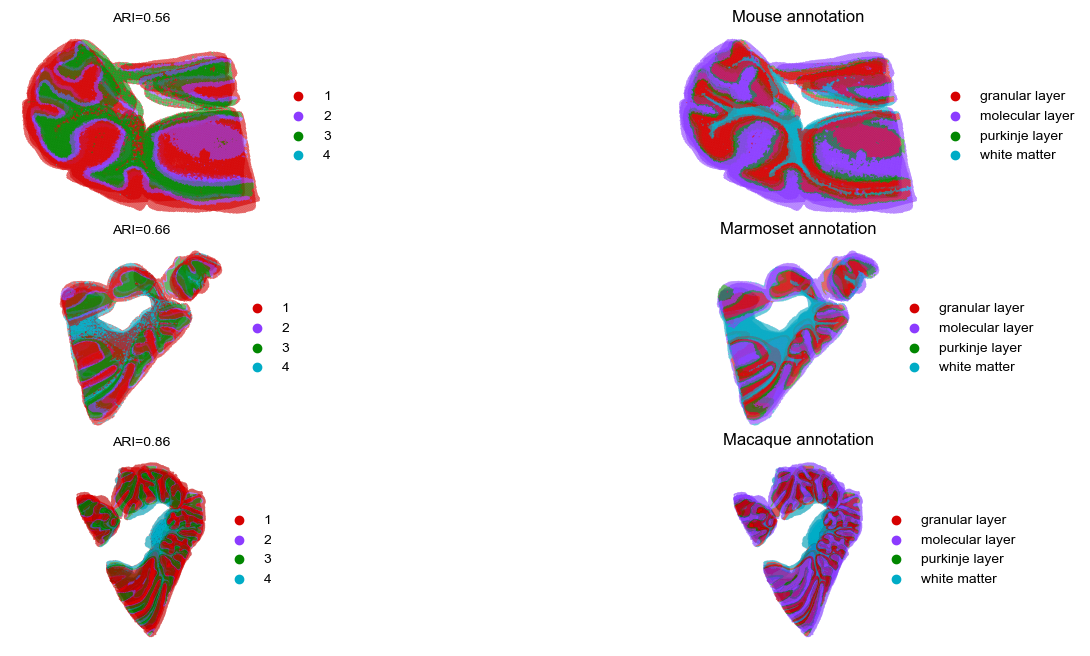

In [13]:


Batch_list = []

for species_id in species_section_ids.keys():
    adata_temp = adata_embedding[adata_embedding.obs['species_id'].isin([species_id])]
    Batch_list.append(adata_temp)

species_list = list(species_section_ids.keys())
spot_size = 1
title_size = 10
ARI_list = []
for bb in range(3):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['annotation'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(3, 2, figsize=(15, 8), gridspec_kw={'wspace': 0.3, 'hspace': 0.1})

clust_list = list(set(list(Batch_list[0].obs['mclust'].unique()) + list(Batch_list[1].obs['mclust'].unique())))
color_list = sns.color_palette(cc.glasbey, n_colors=len(clust_list))
clust_palette = {k:v for k,v in zip(clust_list, color_list)}
palette = {k:clust_palette[k] for k in Batch_list[0].obs['mclust'].unique()}
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[0][0], frameon=False,
                      spot_size=spot_size, palette=palette)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
color_list = sns.color_palette(cc.glasbey, n_colors=len(Batch_list[0].obs['annotation'].unique()))
#palette = {k:v for k,v in zip(Batch_list[0].obs['annotation'].unique(), color_list)}
region_list = ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
color_list = sns.color_palette(cc.glasbey, n_colors=len(region_list))
palette = {k:v for k,v in zip([x for x in region_list], color_list)}
_sc_1 = sc.pl.spatial(Batch_list[0], img_key=None, color=['annotation'], title=[species_list[0] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[0][1], frameon=False,
                      spot_size=spot_size, palette=palette)
palette = {k:clust_palette[k] for k in Batch_list[1].obs['mclust'].unique()}

spot_size = 1
_sc_2 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[1][0], frameon=False,
                      spot_size=spot_size, palette=palette)
_sc_2[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
color_list = sns.color_palette(cc.glasbey, n_colors=len(Batch_list[1].obs['annotation'].unique()))
region_list = ['granular layer', 'molecular layer', 'purkinje layer', 'white matter']
color_list = sns.color_palette(cc.glasbey, n_colors=len(region_list))
palette = {k:v for k,v in zip([x for x in region_list], color_list)}
_sc_3 = sc.pl.spatial(Batch_list[1], img_key=None, color=['annotation'], title=[species_list[1] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[1][1], frameon=False, 
                      spot_size=spot_size, palette=palette)


spot_size = 1
_sc_4 = sc.pl.spatial(Batch_list[2], img_key=None, color=['mclust'], title=['mclust'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[2][0], frameon=False,
                      spot_size=spot_size, palette=clust_palette)
_sc_4[0].set_title("ARI=" + str(ARI_list[2]), size=title_size)

_sc_5 = sc.pl.spatial(Batch_list[2], img_key=None, color=['annotation'], title=[species_list[2] + ' annotation'],
                      legend_loc='right margin', legend_fontsize=10, show=False, ax=ax[2][1], frameon=False, 
                      spot_size=spot_size, palette=palette)

if not os.path.exists(fig_save_path):
    os.makedirs(fig_save_path)
plt.savefig(fig_save_path + 'common_mclust.png')
plt.show()